In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Layer, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Config
SEED = 17
np.random.seed(SEED)
tf.random.set_seed(SEED)



In [150]:
# Step 1: Data Preparation
file_path = "bay_of_bengal_interpolated.csv"
df = pd.read_csv(file_path)

# Convert Date to datetime and sort
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Drop unnecessary columns
df = df.drop(columns=["Unit", "Original_Concentration", "Is_Interpolated"])

# Extract month and day as numerical features
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# Handle categorical variables with simple one-hot encoding
for col in ["Region", "SubRegion", "Sampling_Method", "Density_Class"]:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(columns=[col])

# Make sure all columns except Date are numeric
# Convert any object dtype columns to float
for col in df.columns:
    if col != "Date" and df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col])
        except ValueError:
            print(f"Dropping non-numeric column: {col}")
            df = df.drop(columns=[col])

# Verify all columns (except Date) are numeric
non_numeric_cols = [col for col in df.columns if col != "Date" and not np.issubdtype(df[col].dtype, np.number)]
if non_numeric_cols:
    print(f"Warning: Non-numeric columns found: {non_numeric_cols}")
    df = df.drop(columns=non_numeric_cols)

# Normalize numerical features
num_cols = ["Latitude", "Longitude", "Month", "Day"]
# Only include columns that exist in df
num_cols = [col for col in num_cols if col in df.columns]
scaler_features = MinMaxScaler(feature_range=(0, 1))
df[num_cols] = scaler_features.fit_transform(df[num_cols])

# Normalize target separately
scaler_target = MinMaxScaler(feature_range=(0, 1))
df["Interpolated_Concentration"] = scaler_target.fit_transform(df[["Interpolated_Concentration"]])

# Create input/output sequences
input_window = 60
output_window = 14
feature_cols = [col for col in df.columns if col not in ["Date", "Interpolated_Concentration"]]

X, y = [], []
for i in range(input_window, len(df) - output_window + 1):
    X.append(df.iloc[i - input_window:i][feature_cols].values)
    y.append(df.iloc[i:i + output_window]["Interpolated_Concentration"].values)

X = np.array(X)
y = np.array(y)

# Print data types and check for NaN values
print(f"X data type: {X.dtype}")
print(f"Y data type: {y.dtype}")
print(f"X contains NaN: {np.isnan(X).any()}")
print(f"Y contains NaN: {np.isnan(y).any()}")

# Handle NaN values if present
if np.isnan(X).any():
    X = np.nan_to_num(X)
if np.isnan(y).any():
    y = np.nan_to_num(y)


X data type: float64
Y data type: float64
X contains NaN: False
Y contains NaN: False


In [151]:

# Proper train-validation-test split with chronological ordering
total_samples = len(X)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(f"Training data shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Validation data shape: X_val = {X_val.shape}, y_val = {y_val.shape}")
print(f"Test data shape: X_test = {X_test.shape}, y_test = {y_test.shape}")

Training data shape: X_train = (716, 60, 4), y_train = (716, 14)
Validation data shape: X_val = (153, 60, 4), y_val = (153, 14)
Test data shape: X_test = (154, 60, 4), y_test = (154, 14)


In [152]:

# Simple Attention Layer
class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()
        
    def build(self, input_shape):
        self.W = self.add_weight(name="attention_weight", 
                                shape=(input_shape[-1], 1),
                                initializer="glorot_uniform",
                                trainable=True)
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, inputs):
        # Simple attention mechanism
        score = tf.matmul(inputs, self.W)  # (batch, time_steps, 1)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = inputs * attention_weights
        context_vector = tf.reduce_sum(context_vector, axis=1)  # (batch, features)
        return context_vector

# Build a simple GRU model with attention
def build_simple_gru_attention(input_shape, output_size):
    inputs = Input(shape=input_shape)
    
    # GRU layer
    gru = GRU(64, return_sequences=True)(inputs)
    gru = Dropout(0.2)(gru)
    
    # Attention layer
    attention_vector = AttentionLayer()(gru)
    
    # Output layer
    outputs = Dense(output_size)(attention_vector)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

# Build and train the model
input_shape = X_train.shape[1:]  # (time_steps, features)
output_size = y_train.shape[1]   # prediction horizon
model = build_simple_gru_attention(input_shape, output_size)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model with explicit validation set
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),  # Use explicit validation data
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1589 - mae: 0.3293 - val_loss: 0.0828 - val_mae: 0.2674 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0547 - mae: 0.1891 - val_loss: 0.0512 - val_mae: 0.2080 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0487 - mae: 0.1808 - val_loss: 0.0501 - val_mae: 0.2067 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0483 - mae: 0.1802 - val_loss: 0.0480 - val_mae: 0.2026 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0480 - mae: 0.1797 - val_loss: 0.0460 - val_mae: 0.1982 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0475 - mae: 0.1789 - val_loss: 0.0447 - val_mae: 0.1957 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0473 - mae: 0.1782 - val_loss: 0.0441 - val_mae: 0.1946 - learning_rate: 0.0010
Epoch 8/50
23

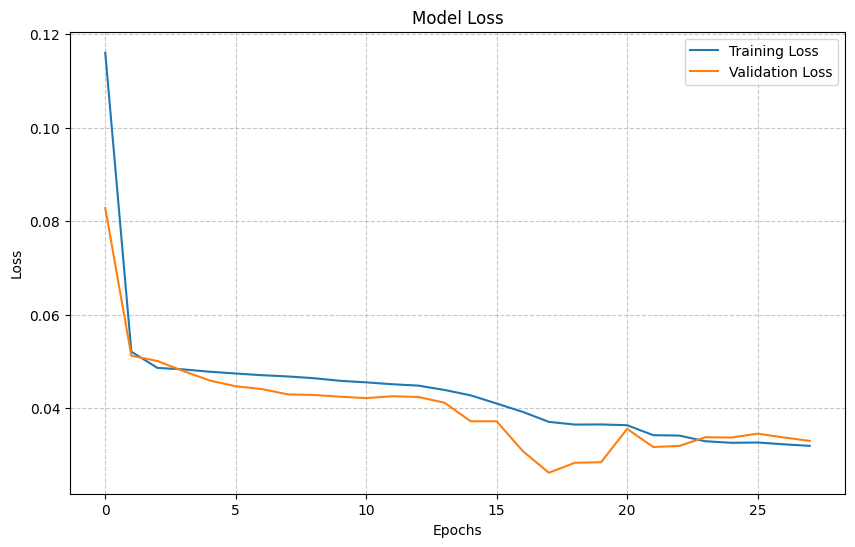

In [153]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Error Metrics on Test Set:
Mean Squared Error (MSE): 0.007372
Root Mean Squared Error (RMSE): 0.085861
Mean Absolute Error (MAE): 0.074390


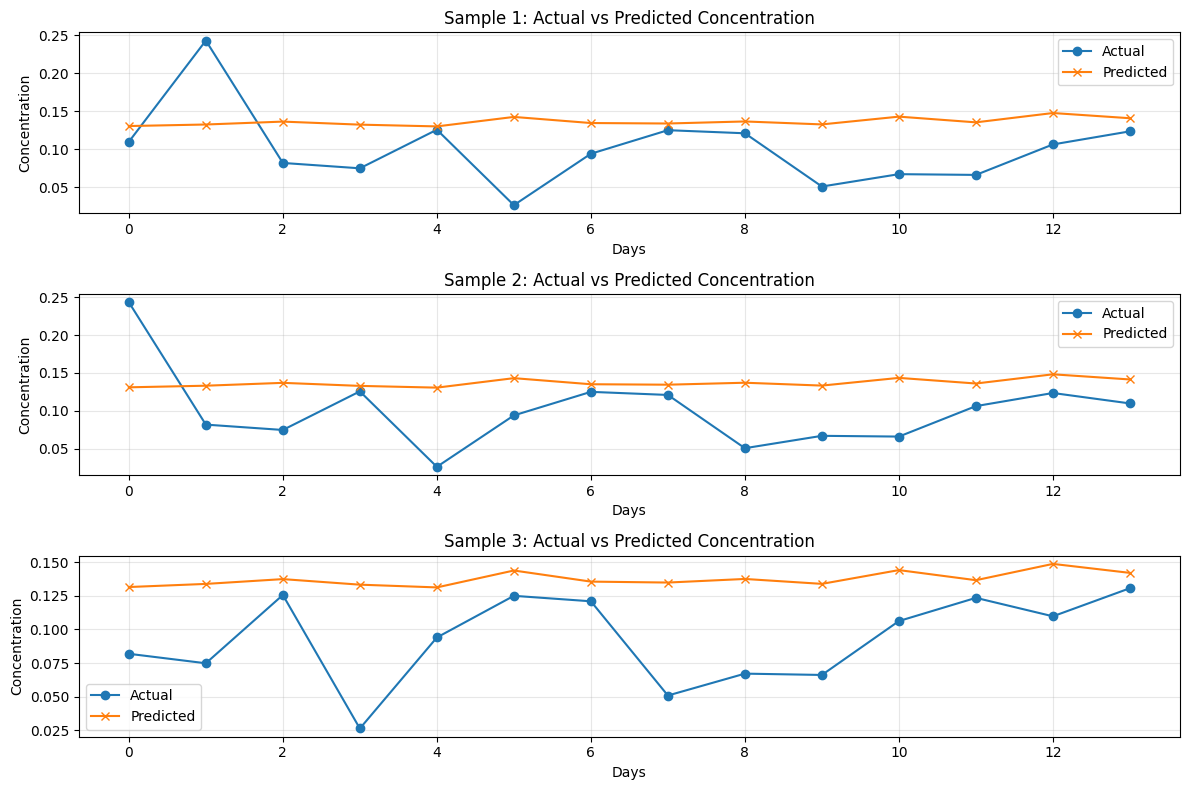

In [154]:
# Evaluate the model on test set
y_pred = model.predict(X_test)

# Inverse transform predictions and true values
y_pred_scaled = scaler_target.inverse_transform(y_pred)
y_test_scaled = scaler_target.inverse_transform(y_test)

# Calculate error metrics
mse = mean_squared_error(y_test_scaled, y_pred_scaled)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
r2 = r2_score(y_test_scaled.flatten(), y_pred_scaled.flatten())

print("\nError Metrics on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")

# Plot actual vs predicted for a few test samples
plt.figure(figsize=(12, 8))
for i in range(min(3, len(y_test))):
    plt.subplot(3, 1, i+1)
    plt.plot(y_test_scaled[i], label='Actual', marker='o')
    plt.plot(y_pred_scaled[i], label='Predicted', marker='x')
    plt.title(f'Sample {i+1}: Actual vs Predicted Concentration')
    plt.xlabel('Days')
    plt.ylabel('Concentration')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()